In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings ('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split

### 1. Data Selection and pre processing

In [3]:
df=pd.read_csv('Pharma_Industry.csv')

In [4]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [5]:
df.shape

(500, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


### Therefore in the given dataset,there are 5 categorical colums and 1 numerical column

In [7]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [8]:
### Checking for missing values
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [9]:
#### checking for duplicate values
df.duplicated().sum()

np.int64(0)

### Hence there are no missing and duplicated values present in the given dataset

In [10]:
#Find Numerical Columns 
numerical_col = df.select_dtypes(include=['int64','float64']).columns
numerical_col


Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

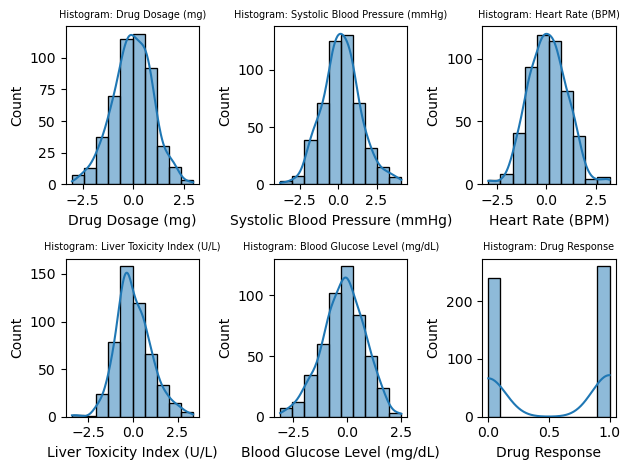

In [11]:
#Plotting Histplot Of Each Numerical Columns  so as to identify Features Distributions
for i, col in enumerate(numerical_col, 1):
    plt.subplot(2,3, i)
    sns.histplot(df[col], kde=True, bins=10) 
    plt.title(f"Histogram: {col}",size=7)
plt.tight_layout()
plt.show()

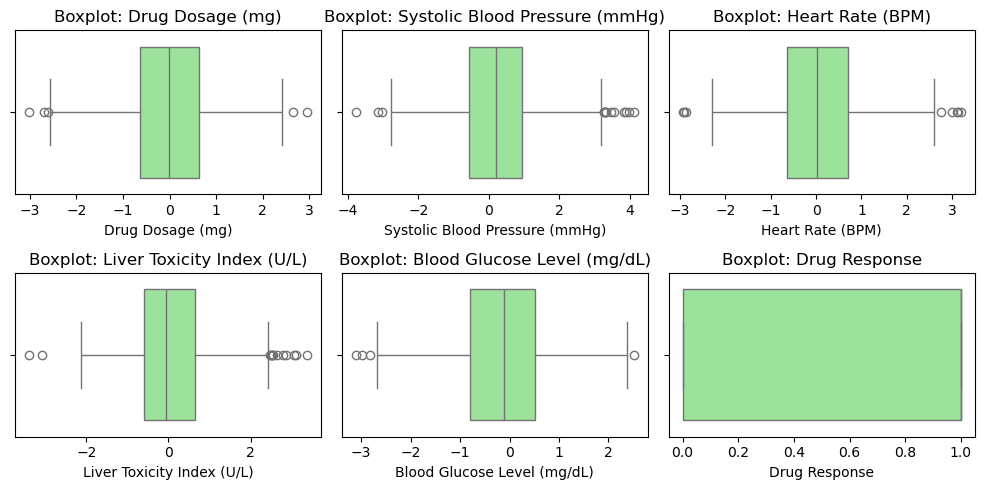

In [12]:
### Now plotting the boxplot 
plt.figure(figsize=(10, 5))
for i, col in enumerate(numerical_col, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color="lightgreen")  
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

In [13]:
#### 3. Finding out the  feature correlations to see relationships within the data

In [14]:
### Outlier capping
def outlier_cappping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_cappping(df,col)

<function matplotlib.pyplot.show(close=None, block=None)>

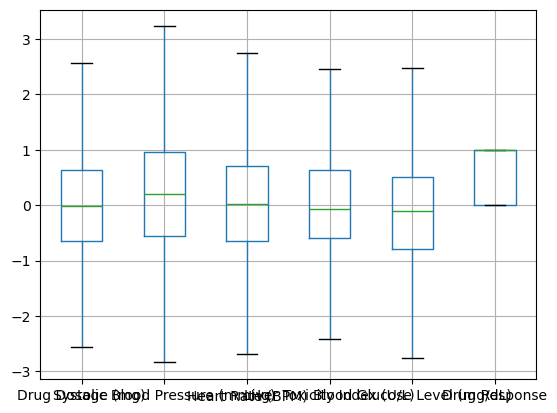

In [15]:
df.boxplot()
plt.show

In [16]:
#Check Correlations Between Features
df.corr()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000000,0.087760,0.040512,0.128059,0.010070,0.043340
Systolic Blood Pressure (mmHg),0.087760,1.000000,-0.041466,0.273864,0.041263,0.308012
Heart Rate (BPM),0.040512,-0.041466,1.000000,0.004618,0.051423,-0.011235
Liver Toxicity Index (U/L),0.128059,0.273864,0.004618,1.000000,0.229714,0.437289
Blood Glucose Level (mg/dL),0.010070,0.041263,0.051423,0.229714,1.000000,0.169445
Drug Response,0.043340,0.308012,-0.011235,0.437289,0.169445,1.000000


<Axes: >

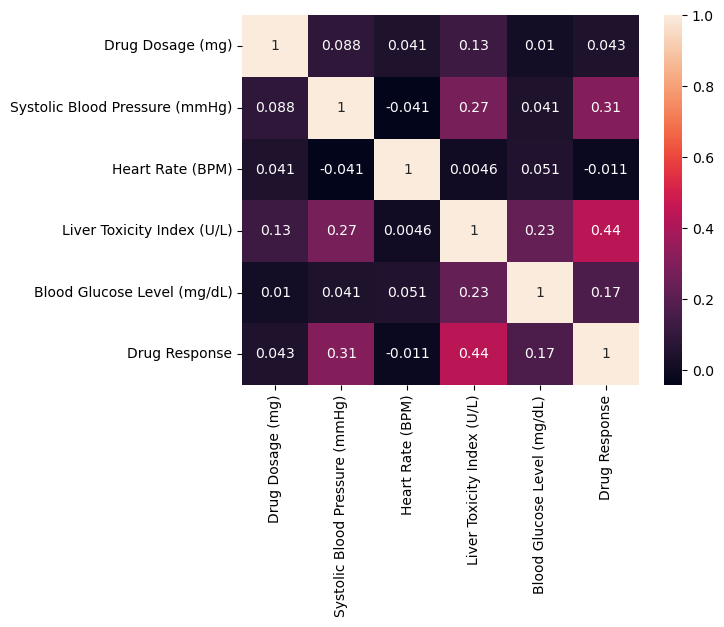

In [17]:
### GEtting the correlation matrix 
sns.heatmap(df.corr(),annot=True)

#### 2. Data Preprocessing
##### Firstly we have to encode the categorical variables present in the dataset

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


##### There are no categorical variables present in the data set

In [19]:
##### Splitting the dataset in testing and training sets
#### First we define features and target

In [20]:
features=df.drop(['Drug Response'],axis=1)
target=df['Drug Response']

In [21]:
### Splitting dataset into training and testing

In [22]:
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=100)

print(x_train.shape)

print(x_test.shape)

print(y_train.shape)

print(y_test.shape)

(400, 5)
(100, 5)
(400,)
(100,)


#### 3. Data Visualization
###### Employing  scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.

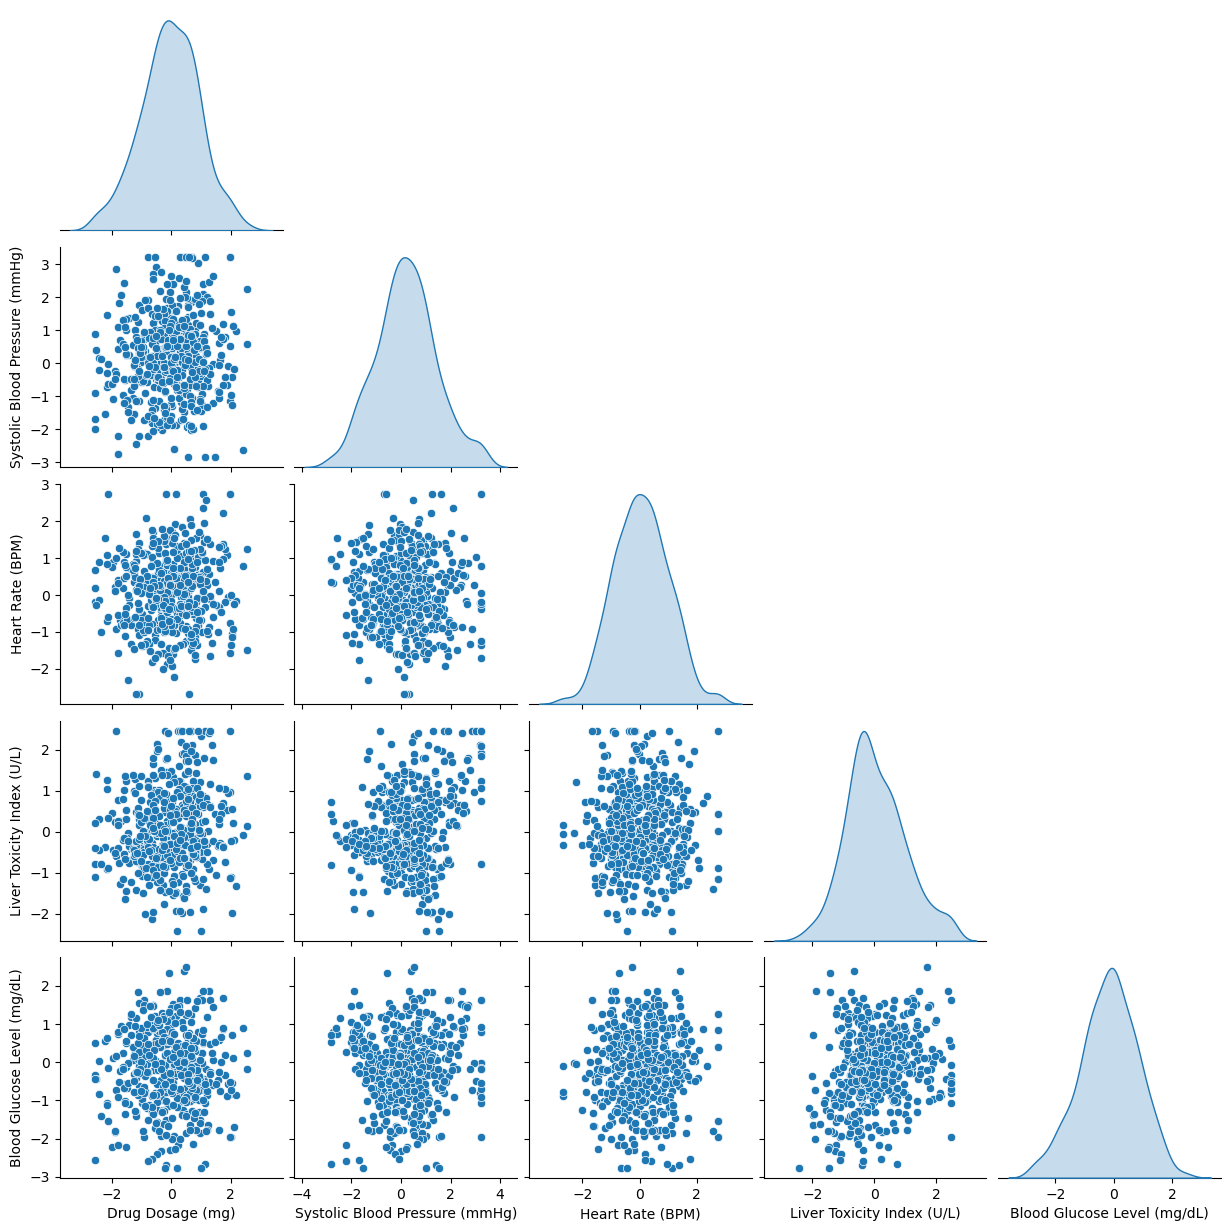

In [23]:
# plotting PairPlot to find feature distributions and relationships between the features.the pair plot represents multiple scatter plots at a time
sns.pairplot(features, diag_kind = 'kde', corner = True) 
plt.show()

<Axes: xlabel='Drug Response', ylabel='count'>

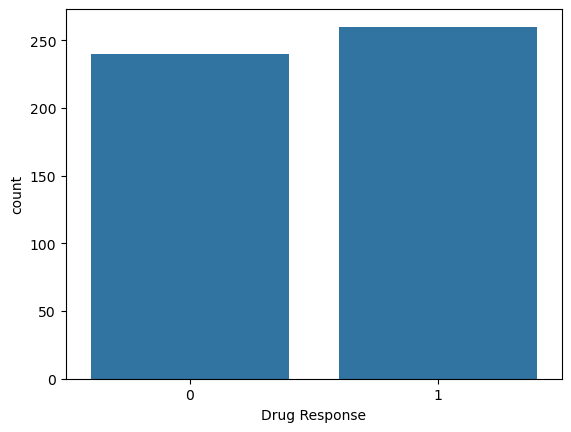

In [27]:
### plotting count plot between the feature distribution to check balancing
sns.countplot(x = target)

In [28]:
#### 4. SVM Implementation
##### Implementing a basic SVM classifier
### we need scikit learn python library to be imported for SVM classifier

In [29]:
### import Support vector classifier  for classification problem
from sklearn.svm import SVC 
svm = SVC()

In [31]:
### Training SVM model on training data and find the predictions made by the model
model = svm.fit(x_train, y_train)
y_pred = model.predict(x_test) 

In [32]:
### Checking accuracy of the training data
model.score(x_train, y_train) 

0.815

In [33]:
### Checking accuracy of testing data
model.score(x_test,y_test)

0.73

### Now evaluating model performance on the testing data using various perfomaance  metrics 

In [34]:
from sklearn.metrics import classification_report , confusion_matrix, f1_score, recall_score, precision_score, roc_curve,roc_auc_score

In [40]:
#Calculating Recall Score
recall = recall_score(y_test, y_pred) 
print("Recall:", np.round(recall,2))

# Calculating precision
precision = precision_score(y_test, y_pred) 
print('precision:', np.round(precision,2))

# Calculating F1-score
f1 = f1_score(y_test, y_pred) 
print("F1-score:", np.round(f1,2))

# Calculating AUC(Area under curve) Score
auc_score = roc_auc_score(y_test, y_pred) 
print(f"AUC Score : {auc_score}")

Recall: 0.7
precision: 0.85
F1-score: 0.77
AUC Score : 0.7410982410982412


In [44]:
#For Cunfusion matrix
cm = confusion_matrix(y_test,y_pred) 
tn, fp, fn, tp = cm.ravel()
print(cm)
print(tn,fp,fn,tp)

[[29  8]
 [19 44]]
29 8 19 44


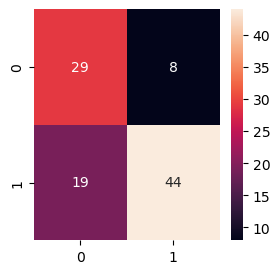

In [47]:
#### Representing SVM classification results using Visualization
 #Plotting heatmap Of Confusion Matrix
plt.figure(figsize=(3,3))
sns.heatmap(cm,annot=True)
plt.show()

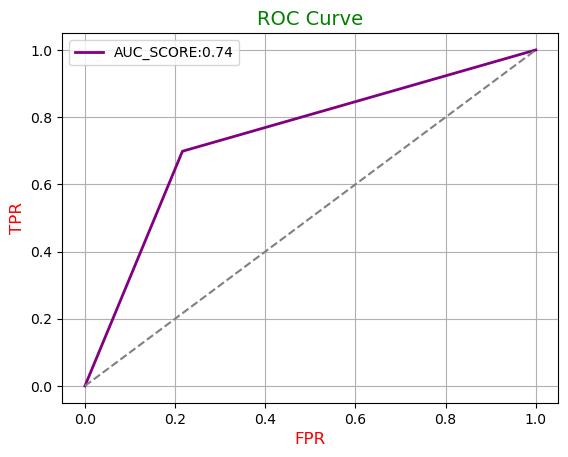

In [51]:
### to find tpr and fpr,and plot the same

fpr,tpr,thr=roc_curve(y_test,y_pred)     

plt.plot(fpr,tpr,color='purple',lw=2,label=f'AUC_SCORE:{auc_score:.2f}')

plt.plot([0,1],linestyle='--',color='grey')

plt.xlabel('FPR',color='red',size=12)

plt.ylabel('TPR',color='red',size=12)

plt.title('ROC Curve',color='green',size=14)

plt.legend()

plt.grid()

plt.show()

In [52]:
### Getting the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.78      0.68        37
           1       0.85      0.70      0.77        63

    accuracy                           0.73       100
   macro avg       0.73      0.74      0.72       100
weighted avg       0.76      0.73      0.73       100



### Parameter Tuning and Optimization
##### Checking out with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

In [54]:
### For hyper parameter tuning
param_grid = {
    'kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree' : [1,2,3,4],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

In [57]:
### from model selection ,we import gridsearch  package so as to find the best parameters
from sklearn.model_selection import GridSearchCV

In [58]:
grid = GridSearchCV(SVC(), param_grid = param_grid) 

In [60]:
#Train with GridSearchCV
grid.fit(x_train, y_train) 

GridSearchCV(estimator=SVC(),
             param_grid={'degree': [1, 2, 3, 4],
                         'gamma': ['scale', 'auto', 0.01, 0.001],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']})

In [61]:
# Predict On GridSearchCV
print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_
y_pred_grid = best_model.predict(x_test) 

recall = recall_score(y_test, y_pred_grid) 
print("Recall:", np.round(recall,2))

precision = precision_score(y_test, y_pred_grid) # Calculating precision
print("Precision:", np.round(precision,2))

f1 = f1_score(y_test, y_pred_grid) # Calculating F1-score
print("F1-score:", np.round(f1,2))

auc_score = roc_auc_score(y_test, y_pred_grid) # Calculating AUC-score
print(f"AUC Score : {auc_score}")

cm = confusion_matrix(y_test,y_pred_grid)
tn, fp, fn, tp = cm.ravel()

Best parameters: {'degree': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Recall: 0.7
Precision: 0.85
F1-score: 0.77
AUC Score : 0.7410982410982412


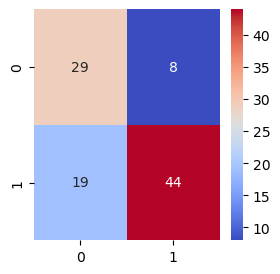

In [62]:
plt.figure(figsize=(3,3))
sns.heatmap(cm,cmap='coolwarm',annot=True)
plt.show()

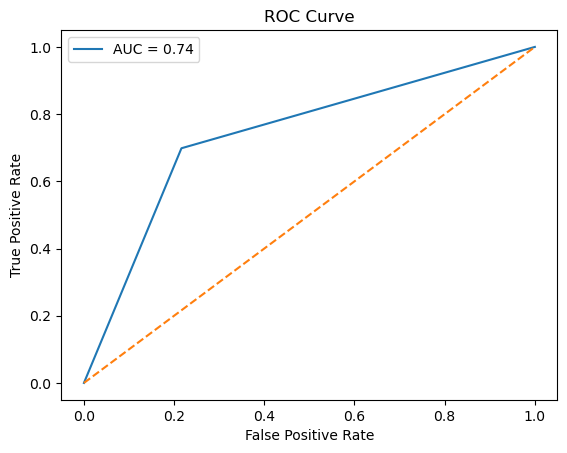

In [63]:
auc_score = roc_auc_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### 7.Comparison and Analysis

##### 1.Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
##### 1. Linear Kernel
It is carriedout on lineardata and gives syraight liine decision boundary
computed using dot product
Pros: It excecutes fast and works best for linear data
cons: It works poor for non-linear data

##### 2.Polynomial(Poly) kernel
It shows curved boundary with polynomial degree
it is used when the data is of non-linear type
pros: it is beneficial in handling of more complex patterns
cons: it is comparitively slower and results in overfitting problem


##### 3: RBF(Radial Basis Function) Kernel
It has Guassian based boundary
works on non linear data
pros: works best on non-linear data
cons: it requires hyperparameter tuning

#### 2.Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.
##### Strengths:
Handles non-linear relationships effectively :
EDA and plots showed overlapping classes, where SVM with RBF kernel performed strongly.

Effective in high-dimensional feature space :
The dataset contained multiple numerical features, and SVM managed them efficiently.

Robust generalization :
Margin maximization reduced overfitting despite class overlap.

##### Weakness:
Highly sensitive to feature scaling :
Initial experiments showed convergence warnings, resolved only after applying StandardScaler.

Computationally expensive :
GridSearchCV with RBF kernel significantly increased training time.
    
Low interpretability :
Unlike linear models, SVM does not provide easily explainable feature importance.
    
Hyperparameter dependent :
Model performance strongly relied on tuning C, gamma, and kernel choice.

#### practical implications of SVM in real-world classification 

1.High Accuracy in Complex Domains
SVM is widely used in domains where precision is critical:
Medical diagnosis: e.g., classifying tumors as benign or malignant.
Text categorization: e.g., spam detection, sentiment analysis.
Image classification: e.g., handwriting or facial recognition.

2. Effective in High-Dimensional Data
SVM performs well in scenarios where the number of features is greater than the number of observations:
e.g., DNA microarray analysis, where each sample may have thousands of gene expression values.

3. Versatile with Kernel Trick
The kernel function enables SVM to handle non-linear data by mapping it to a higher-dimensional space:
Useful in scenarios where relationships between features are complex and non-linear (e.g., pattern recognition, fraud detection).
Common kernels: RBF, polynomial, sigmoid.

4. Robust to Overfitting (Especially in High-Dimensional Space)
SVM uses regularization (C parameter) to avoid overfitting. It's effective when:
